## 1. Environment Setup
Import all libraries and configure notebook warnings/settings before data processing.


In [1]:
import os
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import math
import time
import nltk
import tensorflow as tf
from tensorflow.keras.layers import GRU, LSTM, Bidirectional, Dense, Flatten, Conv1D, BatchNormalization, LeakyReLU, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.utils import plot_model
from pickle import load
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import statsmodels.api as sm
from math import sqrt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from pickle import dump
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load And Inspect Tweet Data
Read the tweet dataset and validate basic schema and stock coverage.


In [2]:
all_tweets = pd.read_csv('stock_tweets.csv')

In [3]:
print(all_tweets.shape)
all_tweets['Stock Name'].unique()

(80793, 4)


array(['TSLA', 'MSFT', 'PG', 'META', 'AMZN', 'GOOG', 'AMD', 'AAPL',
       'NFLX', 'TSM', 'KO', 'F', 'COST', 'DIS', 'VZ', 'CRM', 'INTC', 'BA',
       'BX', 'NOC', 'PYPL', 'ENPH', 'NIO', 'ZS', 'XPEV'], dtype=object)

In [4]:
df = all_tweets #[all_tweets['Stock Name'].isin(stock_names)]
print(df.shape)
df.head()

(80793, 4)


,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80793 entries, 0 to 80792
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          80793 non-null  object
 1   Tweet         80793 non-null  object
 2   Stock Name    80793 non-null  object
 3   Company Name  80793 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


Date            0
Tweet           0
Stock Name      0
Company Name    0
dtype: int64

In [6]:
df['Stock Name'].value_counts()

Stock Name
TSLA    37422
TSM     11034
AAPL     5056
PG       4089
AMZN     4089
MSFT     4089
NIO      3021
META     2751
AMD      2227
NFLX     1727
GOOG     1291
PYPL      843
DIS       635
BA        399
COST      393
INTC      315
KO        310
CRM       233
XPEV      225
ENPH      216
ZS        193
VZ        123
BX         50
NOC        31
F          31
Name: count, dtype: int64

In [7]:
sent_df = df.copy()
sent_df["sentiment_score"] = ''
sent_df["Negative"] = ''
sent_df["Neutral"] = ''
sent_df["Positive"] = ''
sent_df.head()

,Date,Tweet,Stock Name,Company Name,sentiment_score,Negative,Neutral,Positive
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc.",,,,
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc.",,,,
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc.",,,,
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc.",,,,
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc.",,,,


To get sentiment (polarity) scores, we use **VADER (Valence Aware Dictionary for Sentiment Reasoning)** model. VADER is a model used for text sentiment analysis that is sensitive to both polarity (positive/negative) and intensity (strength) of emotion. It is available in the NLTK package and can be applied directly to unlabeled text data.

VADER sentimental analysis relies on a dictionary that maps lexical features to emotion intensities known as sentiment scores. The sentiment score of a text can be obtained by summing up the intensity of each word in the text.

In [8]:
%%time
sentiment_analyzer = SentimentIntensityAnalyzer()
for indx, row in tqdm(sent_df.iterrows(), total=len(sent_df), desc='Sentiment analysis'):
    try:
        sentence_i = unicodedata.normalize('NFKD', sent_df.loc[indx, 'Tweet'])
        sentence_sentiment = sentiment_analyzer.polarity_scores(sentence_i)
        sent_df.at[indx, 'sentiment_score'] = sentence_sentiment['compound']
        sent_df.at[indx, 'Negative'] = sentence_sentiment['neg']
        sent_df.at[indx, 'Neutral'] = sentence_sentiment['neu']
        sent_df.at[indx, 'Positive'] = sentence_sentiment['pos']
    except TypeError:
        print (sent_df.loc[indx, 'Tweet'])
        print (indx)
        break

Sentiment analysis:   0%|          | 0/80793 [00:00<?, ?it/s]

CPU times: user 13.5 s, sys: 229 ms, total: 13.8 s
Wall time: 14 s


In [9]:
sent_df = sent_df.drop(columns=['Company Name'])

In [10]:
sent_df.head()

,Date,Tweet,Stock Name,sentiment_score,Negative,Neutral,Positive
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,0.0772,0.127,0.758,0.115
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,0.0,0.0,1.0,0.0
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,0.296,0.0,0.951,0.049
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,-0.7568,0.273,0.59,0.137
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,-0.875,0.526,0.474,0.0


## 3. Sentiment Feature Engineering
Parse timestamps, run VADER sentiment scoring, and aggregate sentiment features by stock/date windows.


In [11]:
# Define a function to filter DataFrame based on time range
def filter_time_range(df, start_time, end_time):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time'] = df['Date'].dt.time
    df['DateTime'] = df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str)
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    return df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

# Define the time ranges in EST
start_time_est = pd.Timestamp('05:30:00').time()
end_time_est = pd.Timestamp('12:30:00').time()

# Filter DataFrame for two different time ranges
df_within_time_range = filter_time_range(sent_df, start_time_est, end_time_est)
df_outside_time_range = sent_df[~sent_df.index.isin(df_within_time_range.index)]

df_within_time_range['Date'] = pd.to_datetime(df_within_time_range['Date'])
df_within_time_range['Date'] = df_within_time_range['Date'].dt.date

df_outside_time_range['Date'] = pd.to_datetime(df_outside_time_range['Date'])
df_outside_time_range['Date'] = df_outside_time_range['Date'].dt.date

# Aggregate sentiment scores for both time ranges
result_within_time_range = df_within_time_range.groupby(['Stock Name', 'Date']).agg({'sentiment_score': ['mean', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]}).reset_index()
result_within_time_range.columns = ['Stock Name', 'Date', 'Mean', 'Min', 'Max', '25th Percentile', '75th Percentile']

result_outside_time_range = df_outside_time_range.groupby(['Stock Name', 'Date']).agg({'sentiment_score': ['mean', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]}).reset_index()
result_outside_time_range.columns = ['Stock Name', 'Date', 'Mean', 'Min', 'Max', '25th Percentile', '75th Percentile']

print("Results for time range between 5:30 AM EST to 12:30 PM EST:")
print(result_within_time_range)

print("\nResults for time range outside 5:30 AM EST to 12:30 PM EST:")
print(result_outside_time_range)


Results for time range between 5:30 AM EST to 12:30 PM EST:
     Stock Name        Date    Mean     Min     Max  25th Percentile  \
0          AAPL  2021-09-30  0.2739  0.2296  0.3182          0.25175   
1          AAPL  2021-10-07  0.1484     0.0   0.368          0.03860   
2          AAPL  2021-10-08  0.7842  0.7778  0.7906          0.78100   
3          AAPL  2021-10-10  0.3612  0.3612  0.3612          0.36120   
4          AAPL  2021-10-13 -0.4278 -0.4278 -0.4278         -0.42780   
...         ...         ...     ...     ...     ...              ...   
2503         ZS  2022-08-30     0.0     0.0     0.0          0.00000   
2504         ZS  2022-09-01  0.7351  0.7351  0.7351          0.73510   
2505         ZS  2022-09-17  0.8271  0.8271  0.8271          0.82710   
2506         ZS  2022-09-21  0.5122  0.5122  0.5122          0.51220   
2507         ZS  2022-09-29     0.0     0.0     0.0          0.00000   

      75th Percentile  
0             0.29605  
1             0.22260  
2  

In [12]:
sent_df[sent_df['Date'].dt.date == pd.to_datetime('2021-10-13').date()]

,Date,Tweet,Stock Name,sentiment_score,Negative,Neutral,Positive,Time,DateTime
36103,2021-10-13 23:17:31+00:00,"If $TSLA reaches $4,000 by 2025, do the math o...",TSLA,0.4404,0.0,0.83,0.17,23:17:31,2021-10-13 23:17:31
36104,2021-10-13 22:44:18+00:00,Highest $TSLA close in the last 243 days🙌🏻 htt...,TSLA,0.0,0.0,1.0,0.0,22:44:18,2021-10-13 22:44:18
36105,2021-10-13 22:40:15+00:00,"Out of 3,922,516 people \n862,953.52 said no \...",TSLA,0.6083,0.09,0.657,0.253,22:40:15,2021-10-13 22:40:15
36106,2021-10-13 22:28:30+00:00,"@Kristennetten @Tesla @elonmusk Remember, Tabl...",TSLA,0.3182,0.0,0.947,0.053,22:28:30,2021-10-13 22:28:30
36107,2021-10-13 22:00:21+00:00,Another distracted driver crashing into emerge...,TSLA,-0.6124,0.312,0.688,0.0,22:00:21,2021-10-13 22:00:21
...,...,...,...,...,...,...,...,...,...
80272,2021-10-13 08:45:25+00:00,🚨 $NIO NEO Park Constructions 🚧 🦺 🏗 Update.\n\...,NIO,0.8221,0.0,0.833,0.167,08:45:25,2021-10-13 08:45:25
80562,2021-10-13 19:48:24+00:00,Todays plays 🐼\n\n$SPOT 240c hit +77% (2.65 to...,ZS,0.25,0.0,0.962,0.038,19:48:24,2021-10-13 19:48:24
80563,2021-10-13 15:18:31+00:00,The good and bad about this market. Indexes ar...,ZS,0.836,0.095,0.713,0.192,15:18:31,2021-10-13 15:18:31
80564,2021-10-13 14:55:31+00:00,$PANW raro entre las CyberSecurity $ZS $FTNT $...,ZS,0.0,0.0,1.0,0.0,14:55:31,2021-10-13 14:55:31


In [13]:
# Merge results on 'Stock Name' and 'Date'
merged_result = pd.merge(result_within_time_range, result_outside_time_range, on=['Stock Name', 'Date'], suffixes=('_sentiment_intraday', '_outside'))

print(merged_result)

     Stock Name        Date Mean_sentiment_intraday Min_sentiment_intraday  \
0          AAPL  2021-09-30                  0.2739                 0.2296   
1          AAPL  2021-10-07                  0.1484                    0.0   
2          AAPL  2021-10-08                  0.7842                 0.7778   
3          AAPL  2021-10-10                  0.3612                 0.3612   
4          AAPL  2021-10-13                 -0.4278                -0.4278   
...         ...         ...                     ...                    ...   
2335         ZS  2022-01-07                  0.4927                 0.4927   
2336         ZS  2022-02-01                     0.0                    0.0   
2337         ZS  2022-02-22                     0.0                    0.0   
2338         ZS  2022-05-21                 -0.3382                -0.3382   
2339         ZS  2022-09-01                  0.7351                 0.7351   

     Max_sentiment_intraday  25th Percentile_sentiment_intraday

In [14]:
merged_result['Mean_sentiment_before_sod']=merged_result['Mean_outside'].shift(-1) # return a day before the news
merged_result['Min_sentiment_before_sod']=merged_result['Min_outside'].shift(-1)
merged_result['Max_sentiment_before_sod']=merged_result['Max_outside'].shift(-1)
merged_result['25th Percentile_sentiment_before_sod']=merged_result['25th Percentile_outside'].shift(-1)
merged_result['75th Percentile_sentiment_before_sod']=merged_result['75th Percentile_outside'].shift(-1)
merged_result.reset_index(level=0, inplace=True)



In [15]:
tweet_ds = merged_result.drop(['25th Percentile_outside', '75th Percentile_outside', 'Mean_outside', 'Min_outside', 'Max_outside', '25th Percentile_sentiment_intraday', '75th Percentile_sentiment_intraday', '25th Percentile_sentiment_before_sod', '75th Percentile_sentiment_before_sod'], axis=1)
tweet_ds.head()

,index,Stock Name,Date,Mean_sentiment_intraday,Min_sentiment_intraday,Max_sentiment_intraday,Mean_sentiment_before_sod,Min_sentiment_before_sod,Max_sentiment_before_sod
0,0,AAPL,2021-09-30,0.2739,0.2296,0.3182,0.39536,0.0,0.6892
1,1,AAPL,2021-10-07,0.1484,0.0,0.368,0.32482,0.0,0.8538
2,2,AAPL,2021-10-08,0.7842,0.7778,0.7906,0.231475,-0.4215,0.8597
3,3,AAPL,2021-10-10,0.3612,0.3612,0.3612,-0.01315,-0.5859,0.2023
4,4,AAPL,2021-10-13,-0.4278,-0.4278,-0.4278,0.516231,0.0,0.893


As the result of sentiment analysis we get average polarity scores of all tweets about a cartain stock ticker for each day:

<a id="section-three"></a>
# Get final dataset for training

## 4. Load Stock Market Data
Read OHLCV stock data and merge it with sentiment aggregates for supervised learning.


In [16]:
all_stocks = pd.read_csv('stock_yfinance_data.csv')
print(all_stocks.shape)
all_stocks.head()
all_stocks['Stock Name'].unique()
all_stocks

(6300, 8)


,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA
...,...,...,...,...,...,...,...,...
6295,2022-09-23,13.090000,13.892000,12.860000,13.710000,13.710000,28279600,XPEV
6296,2022-09-26,14.280000,14.830000,14.070000,14.370000,14.370000,27891300,XPEV
6297,2022-09-27,14.580000,14.800000,13.580000,13.710000,13.710000,21160800,XPEV
6298,2022-09-28,13.050000,13.421000,12.690000,13.330000,13.330000,31799400,XPEV


In [17]:
stock_df = all_stocks
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['Date'] = stock_df['Date'].dt.date

In [18]:
stock_df.columns
stock_df['Stock Name'].unique()

array(['TSLA', 'MSFT', 'PG', 'META', 'AMZN', 'GOOG', 'AMD', 'AAPL',
       'NFLX', 'TSM', 'KO', 'F', 'COST', 'DIS', 'VZ', 'CRM', 'INTC', 'BA',
       'BX', 'NOC', 'PYPL', 'ENPH', 'NIO', 'ZS', 'XPEV'], dtype=object)

In [19]:
final_df = pd.merge(stock_df, tweet_ds, on=['Stock Name', 'Date'])
print(final_df.shape)

(1743, 15)


In [20]:
final_df['Stock Name'].value_counts()

Stock Name
TSLA    252
TSM     206
NIO     193
AAPL    174
PG      152
AMZN    152
MSFT    152
META    100
AMD      97
GOOG     86
NFLX     48
PYPL     28
DIS      21
INTC     18
XPEV     16
BA       11
COST      9
KO        8
ZS        7
CRM       5
VZ        3
ENPH      2
BX        1
NOC       1
F         1
Name: count, dtype: int64

In [21]:
final_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,index,Mean_sentiment_intraday,Min_sentiment_intraday,Max_sentiment_intraday,Mean_sentiment_before_sod,Min_sentiment_before_sod,Max_sentiment_before_sod
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,1654,0.228995,-0.9423,0.8331,0.21787,-0.8689,0.9313
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,1655,0.277408,-0.8176,0.9305,0.272467,-0.8217,0.9632
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,1658,0.07683,-0.5766,0.7278,0.090785,-0.8885,0.9467
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,1659,0.009139,-0.875,0.7003,0.219249,-0.6908,0.9732
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,1660,0.147529,-0.5267,0.8122,0.187267,-0.9169,0.923


In [22]:
def event_return(df):
    #Computing the return
    df['close_pct_change'] = df['Close'].pct_change()
    df['vol_pct_change'] = df['Volume'].pct_change()
    
    df['high_low_diff'] = df['High'] - df['Low']
    df['open_close_diff'] = df['Open'] - df['Close']
    
    
    df['market_up'] = df['Open'] - df['Close']
    df['vol_weekly_diff'] = df['Volume'].shift(7)
    
    df['ret_curr'] = df['High'] - df['Low']

    #Computing the event return
    rtm1 = df['ret_curr'].shift(-1) # return a day before the news
    rtp1 = df['ret_curr'].shift(1) # return a day after the news
    rt = df['ret_curr'] # return the day of the news

    df['eventRet'] = rt + rtp1 
    df.reset_index(level=0, inplace=True)

    df['date'] = pd.to_datetime(df['Date']).apply(lambda x: x.date())

In [23]:
event_return(final_df)

In [24]:
cpc = final_df['close_pct_change'].dropna()
min(cpc)

-0.8351226281268689

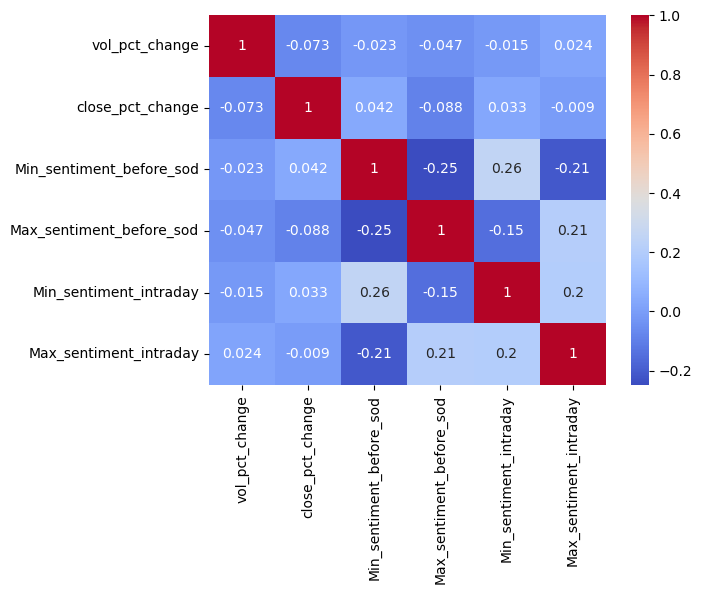

In [25]:
related_cols = ['vol_pct_change', 'close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 'Min_sentiment_intraday', 'Max_sentiment_intraday']
sns.heatmap(final_df[related_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [26]:
# Define a function to apply the condition element-wise
def classify_movement(change):
    if change > 0.05:
        return 1
    elif change < -0.05:
        return -1
    else :
        return 0
# Apply the function to each value in the 'close_pct_change' column
final_df['market_movement'] = final_df['close_pct_change'].apply(classify_movement)

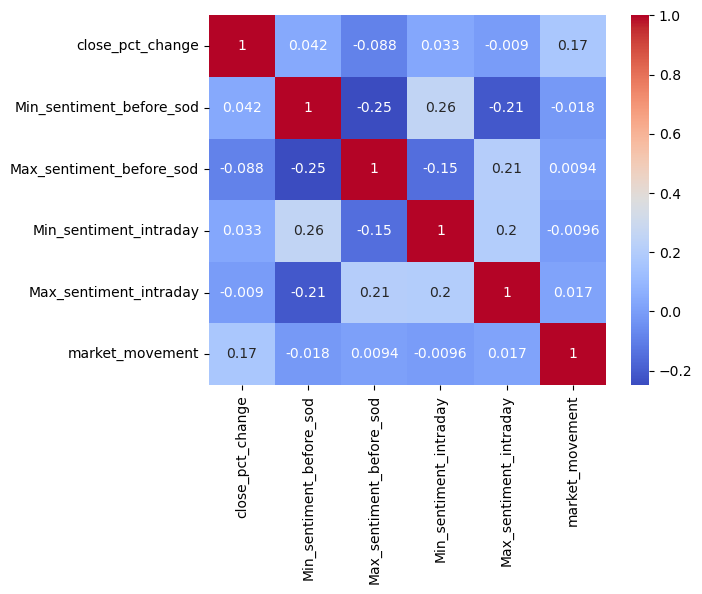

In [27]:
final_df['market_movement'].value_counts()

final_df['market_movement'].value_counts()
required_cols = ['close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 'Min_sentiment_intraday', 'Max_sentiment_intraday', 'market_movement']

final_market_df = final_df[required_cols]
sns.heatmap(final_market_df[required_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [28]:
# Handling missing values
final_market_df.dropna(inplace=True) 

# Resetting index
final_market_df.reset_index(drop=True, inplace=True)

## 5. Baseline ML Models
Train and compare baseline classifiers (Random Forest, Logistic Regression, SVM).


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [30]:
# Define the required columns and the target variable
required_cols = ['close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 
                 'Min_sentiment_intraday', 'Max_sentiment_intraday']
target_col = 'market_movement'

# Splitting the data into features (X) and target variable (y)
X = final_market_df[required_cols]
y = final_market_df[target_col]

# Splitting the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier()

In [31]:
rf_classifier.fit(X_train, y_train)
# Predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


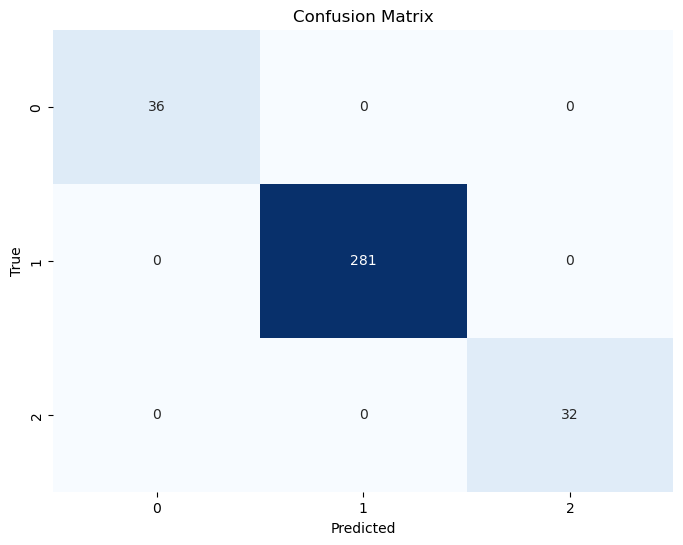

In [32]:
# Calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg = LogisticRegression()


log_reg.fit(X_train, y_train)

LogisticRegression()

In [34]:
# Predictions on the test set
y_pred_log = log_reg.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy}")

Accuracy: 0.833810888252149


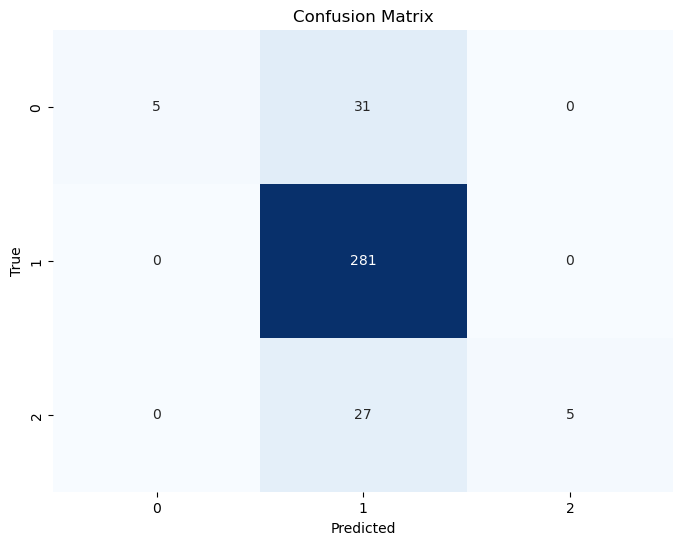

In [35]:
# Calculate confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [36]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm}")

Accuracy: 0.8252148997134671


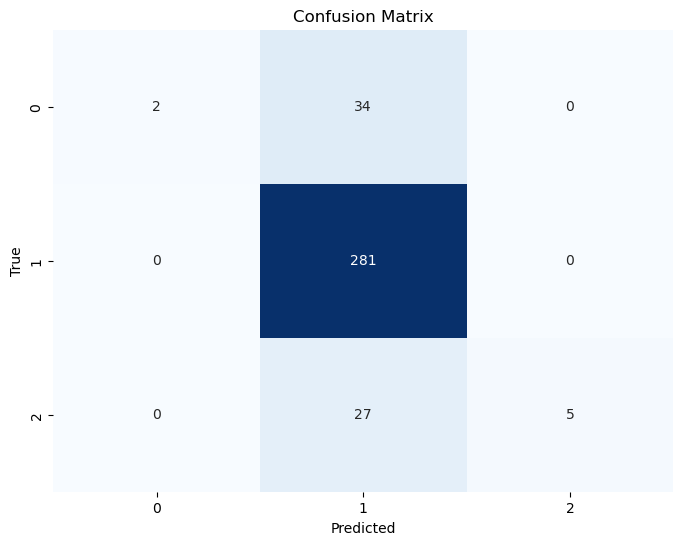

In [37]:
# Calculate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [38]:
def linear_correlation(data_df):
    ticker_dict = dict(tuple(data_df.groupby('Stock Name')))
    #print(ticker_dict)
    lst_corrs = []; lst_keys = []
    for key,value in ticker_dict.items():
        corr_matrix = data_df.corr()
        #print(corr_matrix)
        print(key)
        print("value")
        print(value)
        corr_val = ticker_dict[key]['eventRet'].corr(ticker_dict[key]['sentiment_score'])
        lst_keys.append(key)
        lst_corrs.append(round(corr_val,3))


    ddf = pd.DataFrame(zip(lst_keys,lst_corrs))
    ddf.columns = ['Stock Name','corr']

    fig = px.bar(ddf,x='Stock Name',y='corr',template='plotly_white',
                 width=None,height=400,title='Adj Close & sentiment correlation')

    fig.show(renderer='iframe')
    linear_correlation(final_df)

## 6. XGBoost Pipeline
Build a stock-specific XGBoost classifier using cleaned numeric features and encoded targets.


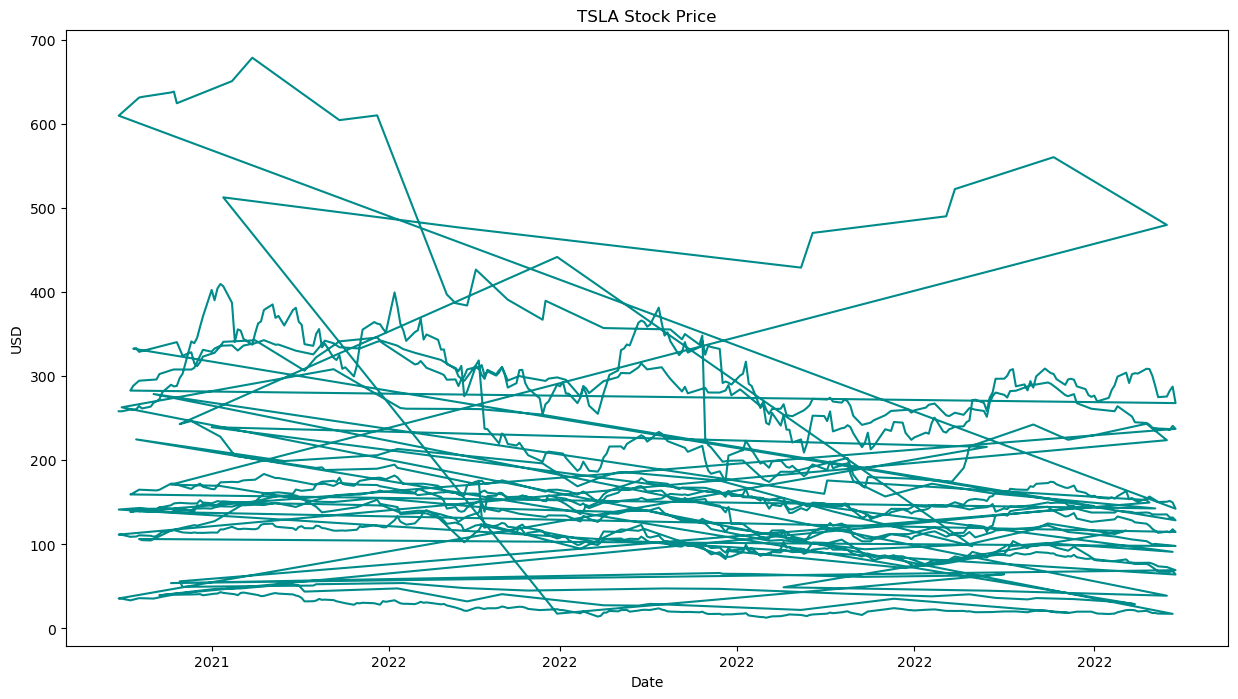

In [39]:
stock_name = 'TSLA'
fig, ax = plt.subplots(figsize=(15,8))
ax.plot(final_df['Date'], final_df['Close'], color='#008B8B')
ax.set(xlabel="Date", ylabel="USD", title=f"{stock_name} Stock Price")
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [41]:
required_cols = ['close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 
                 'Min_sentiment_intraday', 'Max_sentiment_intraday']
target_col = 'market_movement'

# Splitting the data into features (X) and target variable (y)
X = final_market_df[required_cols]
y = final_market_df[target_col]

# Splitting the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep only numeric columns
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Initialize label encoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost model
xgb_model = XGBClassifier()

# Train the model
xgb_model.fit(X_train, y_train_encoded)

# Predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.997134670487106


### Adding technical indicators

To help the network understand the bigger picture of the market we add different technical indicators to the training data, such as moving averages, Bollinger bands etc., which describe the development of stock price not only for the current day, but for the past week or more.

**MA(7)** stans for Moving Average for past 7 days, whereas **MA(20)** means Moving Average for past 20 days.

**EMA** is Exponential Moving average and we can calculate it as:
* *EMA_t = Pclose + (EMA_t-1 * (100 - P))*

**Bollinger Bands** are calculated as:
* middle line: *stdev(MA(20))*
* upper bound: *MA(20) + 2stdev(MA(20))*
* lower bound: *MA(20) - 2stdev(MA(20))*

## 7. Technical Indicators
Generate MA, MACD, EMA, Bollinger Bands, and momentum features for sequence modeling.


In [42]:
def get_tech_ind(data):
    data['MA7'] = data['Close'].rolling(window=7).mean() #Close column
    data['MA20'] = data['Close'].rolling(window=20).mean() #Close Column

    data['MACD'] = data['Close'].ewm(span=26).mean() - data['Open'].ewm(span=12,adjust=False).mean()
    #This is the difference of Closing price and Opening Price

    # Create Bollinger Bands
    data['20SD'] = data['Close'].rolling(20).std()
    data['upper_band'] = data['MA20'] + (data['20SD'] * 2)
    data['lower_band'] = data['MA20'] - (data['20SD'] * 2)

    # Create Exponential moving average
    data['EMA'] = data['Close'].ewm(com=0.5).mean()

    # Create LogMomentum
    data['logmomentum'] = np.log(data['Close'] - 1)

    return data

In [43]:
tech_df = get_tech_ind(final_df)
dataset = tech_df.iloc[20:,:].reset_index(drop=True)
numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
if 'Date' in dataset.columns:
    dataset = dataset[['Date'] + [col for col in numeric_cols if col != 'Date']]
else:
    dataset = dataset[numeric_cols]
dataset.head()

dataset.shape

tech_df.head(20)

tech_df.shape

(1743, 34)

In [44]:
def tech_ind(dataset):
    fig,ax = plt.subplots(figsize=(15, 8), dpi = 200)
    x_ = range(3, dataset.shape[0])
    x_ = list(dataset.index)

    ax.plot(dataset['Date'], dataset['MA7'], label='Moving Average (7 days)', color='g', linestyle='--')
    ax.plot(dataset['Date'], dataset['Close'], label='Closing Price', color='#6A5ACD')
    ax.plot(dataset['Date'], dataset['MA20'], label='Moving Average (20 days)', color='r', linestyle='-.')
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    plt.title('Technical indicators')
    plt.ylabel('Close (USD)')
    plt.xlabel("Year")
    plt.legend()

    plt.show()

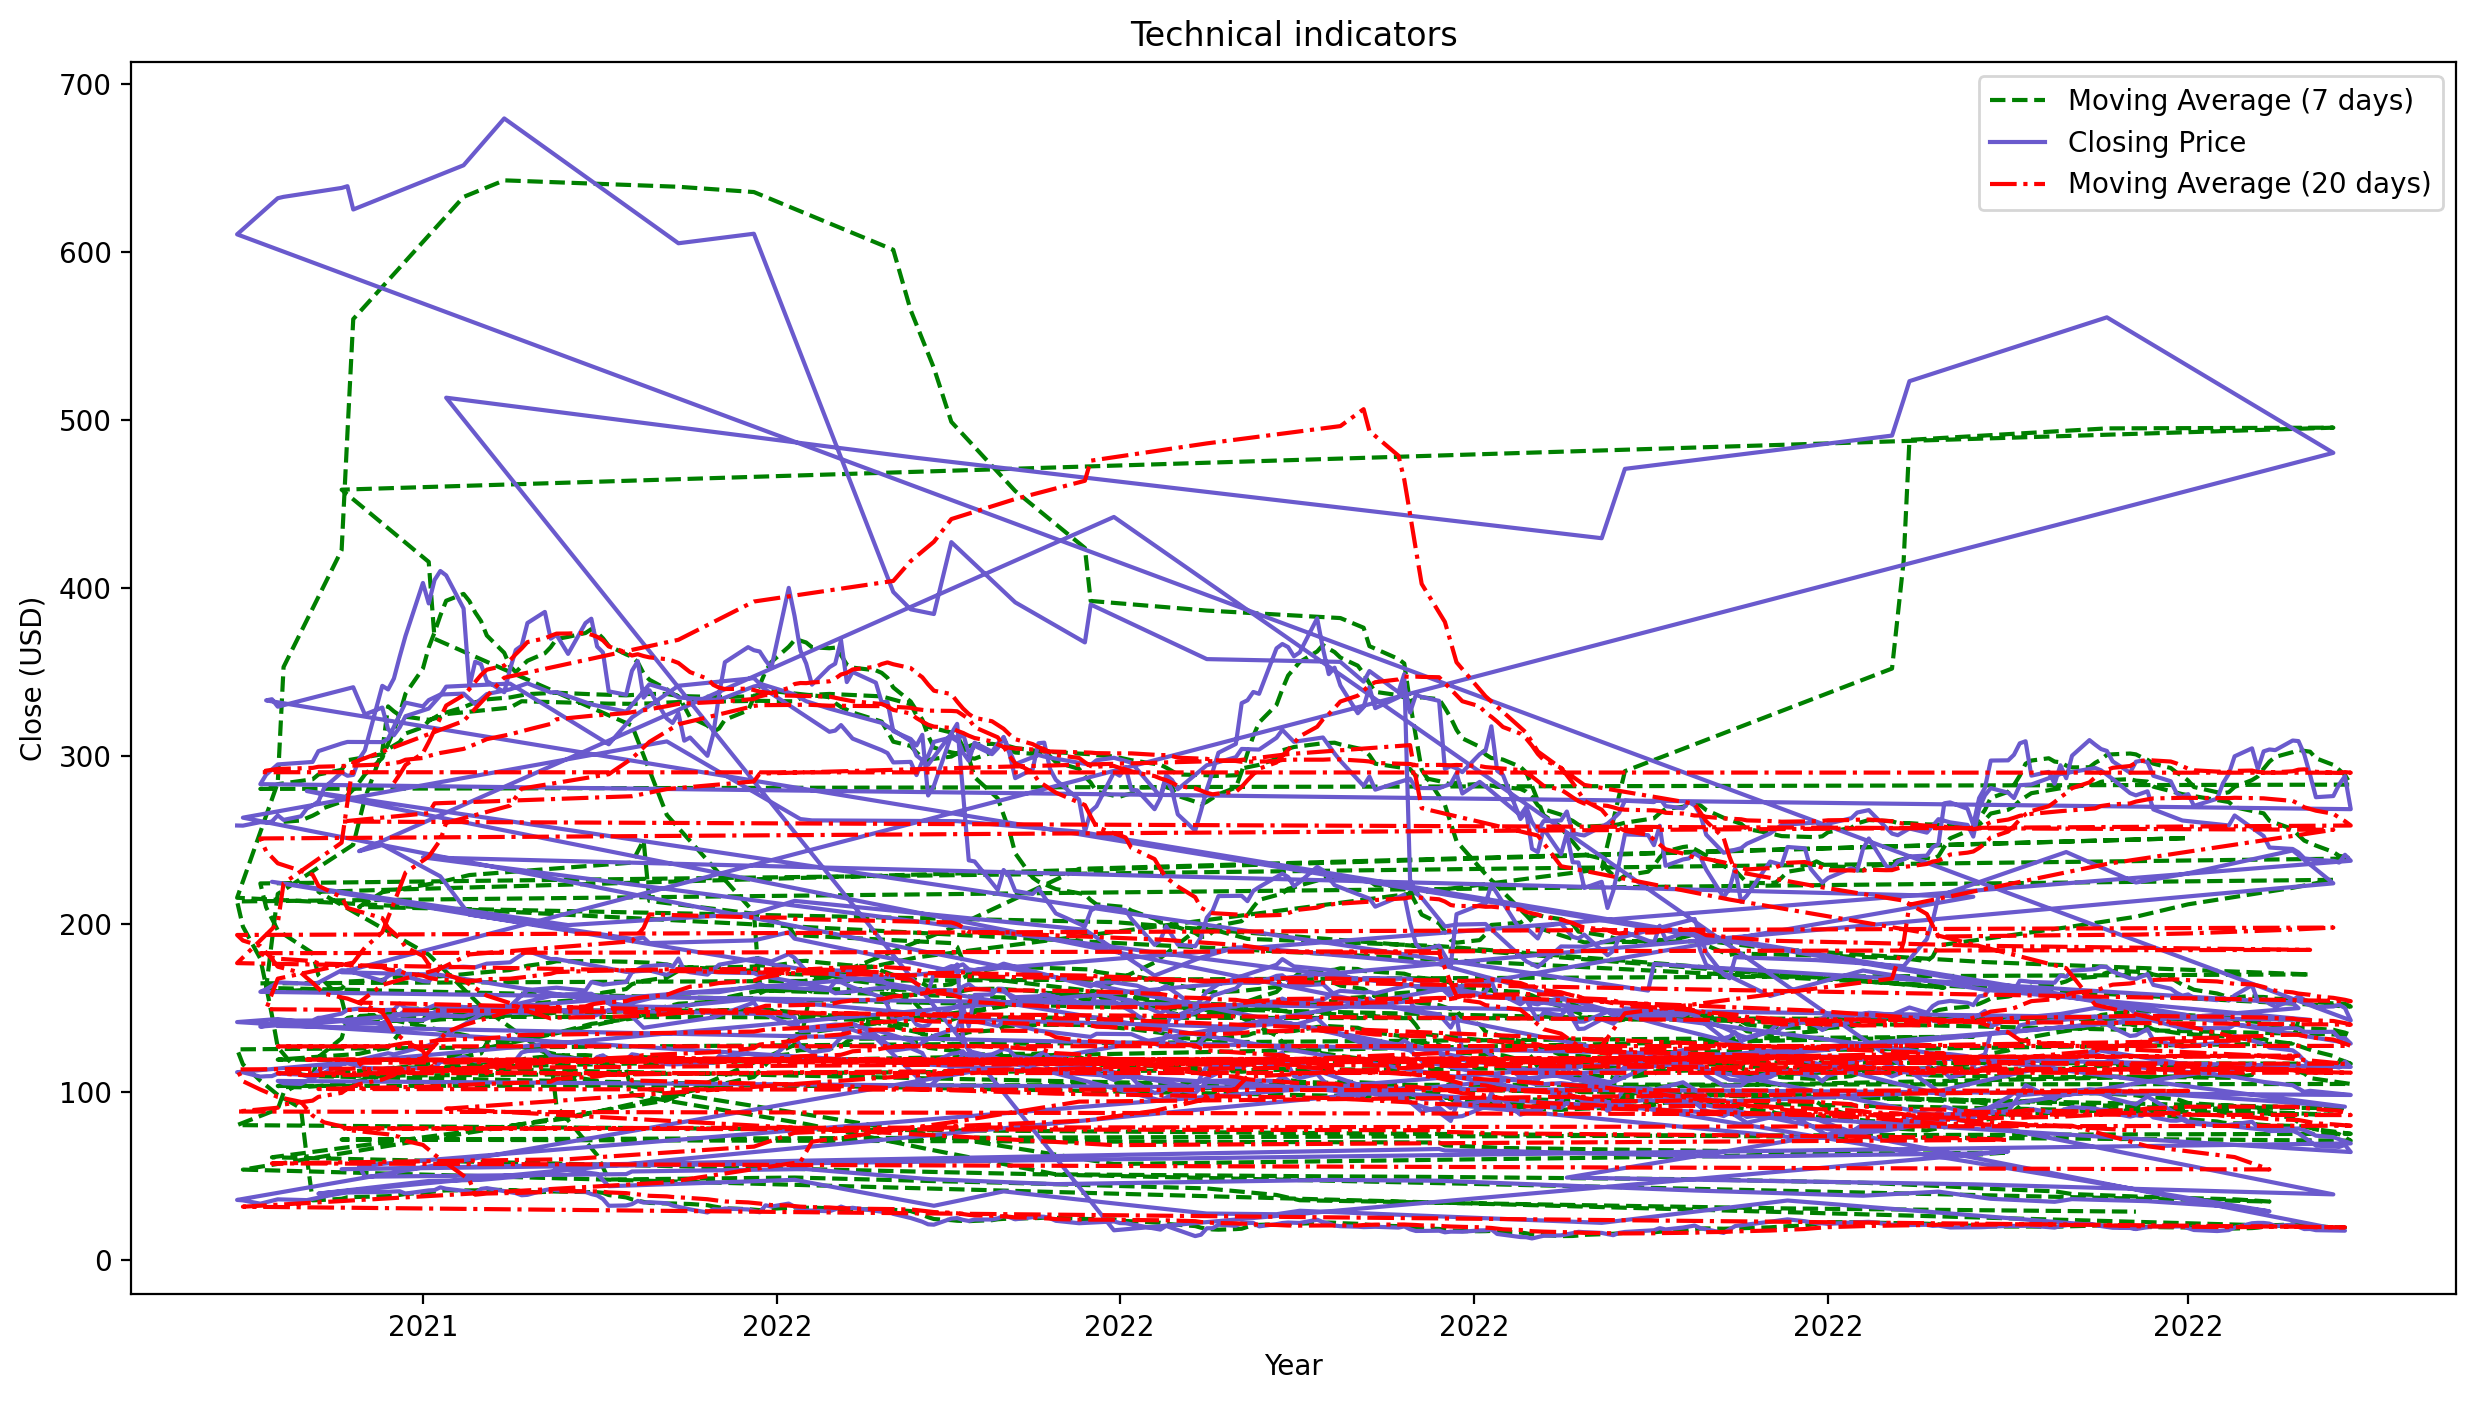

In [45]:
tech_ind(tech_df)

if 'Date' in dataset.columns:
    feature_cols = [col for col in dataset.columns if col != 'Date']
    dataset.loc[:, feature_cols] = dataset[feature_cols].ffill()
    datetime_series = pd.to_datetime(dataset['Date'])
    datetime_index = pd.DatetimeIndex(datetime_series.values)
    dataset = dataset.set_index(datetime_index)
    dataset = dataset.sort_values(by='Date')
    dataset = dataset.drop(columns='Date')
else:
    dataset = dataset.ffill()
    dataset.index = pd.to_datetime(dataset.index, errors='coerce')
    dataset = dataset.sort_index()


In [46]:
dataset.head()

,level_0,Open,High,Low,Close,Adj Close,Volume,index,close_pct_change,vol_pct_change,...,eventRet,market_movement,MA7,MA20,MACD,20SD,upper_band,lower_band,EMA,logmomentum
2021-09-30,991,143.660004,144.380005,141.279999,141.500000,140.478485,89056700,0,1.206112,-0.131598,...,7.470001,1,80.164285,88.253000,0.453836,18.014783,124.282565,52.223435,116.180434,4.945207
2021-09-30,1165,608.049988,619.000000,608.049988,610.340027,610.340027,6612600,1082,3.283689,-0.948395,...,16.990021,1,215.480002,176.574000,-33.349294,102.181936,380.937872,-27.789872,455.266507,6.412376
2021-09-30,1213,112.430000,113.349998,111.650002,111.650002,109.457535,6433400,2019,-0.501718,-0.218707,...,11.389999,-1,213.297144,193.335501,23.072806,31.104941,255.545382,131.125620,150.755056,4.706372
2021-09-30,1527,35.630001,35.980000,35.290001,35.630001,35.630001,25768500,1149,-0.835123,7.326655,...,7.189999,-1,125.260002,113.310251,8.706902,47.918606,209.147462,17.473040,92.958156,3.544720
2021-10-01,1214,112.000000,112.300003,110.300003,111.559998,109.369293,5315200,2020,-0.000806,-0.173812,...,3.699997,0,198.314286,190.030500,28.353853,35.986752,262.004005,118.056996,124.625017,4.705558


In [47]:
def normalize_data(df, range, target_column):

    '''
    df: dataframe object
    range: type tuple -> (lower_bound, upper_bound)
        lower_bound: int
        upper_bound: int
    target_column: type str -> should reflect closing price of stock
    '''

    target_df_series = pd.DataFrame(df[target_column])
    data = pd.DataFrame(df.iloc[:, :])

    print(data.columns)
    
    X_scaler = MinMaxScaler(feature_range=range)
    y_scaler = MinMaxScaler(feature_range=range)
    X_scaler.fit(data)
    y_scaler.fit(target_df_series)

    X_scale_dataset = X_scaler.fit_transform(data)
    y_scale_dataset = y_scaler.fit_transform(target_df_series)
    
    dump(X_scaler, open('X_scaler.pkl', 'wb'))
    dump(y_scaler, open('y_scaler.pkl', 'wb'))

    return (X_scale_dataset,y_scale_dataset)

In [48]:
def batch_data(x_data,y_data, batch_size, predict_period):
    X_batched, y_batched, yc = list(), list(), list()

    for i in range(0,len(x_data),1):
        x_value = x_data[i: i + batch_size][:, :]
        y_value = y_data[i + batch_size: i + batch_size + predict_period][:, 0]
        yc_value = y_data[i: i + batch_size][:, :]
        if len(x_value) == batch_size and len(y_value) == predict_period:
            X_batched.append(x_value)
            y_batched.append(y_value)
            yc.append(yc_value)

    return np.array(X_batched), np.array(y_batched), np.array(yc)

In [49]:
def split_train_test(data):
    train_size = len(data) - 20
    data_train = data[0:train_size]
    data_test = data[train_size:]
    #print(len(data_train), len(data_test))
    return data_train, data_test

In [50]:
def predict_index(dataset, X_train, batch_size, prediction_period):

    # get the predict data (remove the in_steps days)
    train_predict_index = dataset.iloc[batch_size: X_train.shape[0] + batch_size + prediction_period, :].index
    test_predict_index = dataset.iloc[X_train.shape[0] + batch_size:, :].index

    return train_predict_index, test_predict_index

## 8. Sequence Dataset Prep
Scale features, create batched windows, and split train/test sequences for GAN training.


In [51]:
X_scale_dataset,y_scale_dataset = normalize_data(dataset, (-1,1), "Close")
X_batched, y_batched, yc = batch_data(X_scale_dataset, y_scale_dataset, batch_size = 5, predict_period = 1)

X_train, X_test, = split_train_test(X_batched)
y_train, y_test, = split_train_test(y_batched)

yc_train, yc_test, = split_train_test(yc)
index_train, index_test, = predict_index(dataset, X_train, 5, 1)


Index(['level_0', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'index', 'close_pct_change', 'vol_pct_change', 'high_low_diff',
       'open_close_diff', 'market_up', 'vol_weekly_diff', 'ret_curr',
       'eventRet', 'market_movement', 'MA7', 'MA20', 'MACD', '20SD',
       'upper_band', 'lower_band', 'EMA', 'logmomentum'],
      dtype='object')


In [52]:
print (X_scale_dataset)

input_dim = X_train.shape[1] 
feature_size = X_train.shape[2] 
output_dim = y_train.shape[1]

[[ 0.12775842 -0.61009942 -0.61240124 ... -0.03530652 -0.68479273
   0.22426585]
 [ 0.32984901  0.78078949  0.80247426 ... -0.33252243  0.35141051
   0.94715327]
 [ 0.38559814 -0.70363603 -0.70490387 ...  0.25778203 -0.57913716
   0.10658949]
 ...
 [ 0.01393728 -0.74296153 -0.74678789 ...  0.13327083 -0.73715195
   0.04217579]
 [-0.55516841 -0.32487719 -0.32750039 ...  0.58423009 -0.3118336
   0.48083952]
 [ 0.12659698 -0.83925362 -0.84248026 ... -0.00815885 -0.83953938
  -0.16982896]]


<a id="section-four"></a>
# Build GAN model

## 9. GAN Architecture
Define generator/discriminator networks and adversarial training objectives.


In [53]:
def make_generator_model(input_dim, output_dim, feature_size):
    model = tf.keras.Sequential([LSTM(units = 1024, return_sequences = True, 
                                    input_shape=(input_dim, feature_size),recurrent_dropout = 0.3),
                               LSTM(units = 512, return_sequences = True, recurrent_dropout = 0.3),
                               LSTM(units = 256, return_sequences = True, recurrent_dropout = 0.3),
                               LSTM(units = 128, return_sequences = True, recurrent_dropout = 0.3),
                               LSTM(units = 64, recurrent_dropout = 0.3),
                               Dense(32),
                               Dense(16),
                               Dense(8),
                               Dense(units=output_dim)])
    return model

In [54]:
def make_discriminator_model(input_dim):
    cnn_net = tf.keras.Sequential()
    cnn_net.add(Conv1D(8, input_shape=(input_dim+1, 1), kernel_size=3, strides=2, padding='same', activation=LeakyReLU(alpha=0.01)))
    cnn_net.add(Conv1D(16, kernel_size=3, strides=2, padding='same', activation=LeakyReLU(alpha=0.01)))
    cnn_net.add(Conv1D(32, kernel_size=3, strides=2, padding='same', activation=LeakyReLU(alpha=0.01)))
    cnn_net.add(Conv1D(64, kernel_size=3, strides=2, padding='same', activation=LeakyReLU(alpha=0.01)))
    cnn_net.add(Conv1D(128, kernel_size=1, strides=2, padding='same', activation=LeakyReLU(alpha=0.01)))
    #cnn_net.add(Flatten())
    cnn_net.add(LeakyReLU())
    cnn_net.add(Dense(220, use_bias=False))
    cnn_net.add(LeakyReLU())
    cnn_net.add(Dense(220, use_bias=False, activation='relu'))
    cnn_net.add(Dense(1, activation='sigmoid'))
    return cnn_net

Now we define loss functions for our models. We will use BinaryCrossEntropy loss for both models:

In [55]:
def discriminator_loss(real_output, fake_output):
    loss_f = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    real_loss = loss_f(tf.ones_like(real_output), real_output)
    fake_loss = loss_f(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    loss_f = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    loss = loss_f(tf.ones_like(fake_output), fake_output)
    return loss


In [56]:
@tf.function
def train_step(real_x, real_y, yc, generator, discriminator, g_optimizer, d_optimizer):
    real_x = tf.cast(real_x, tf.float32)
    real_y = tf.cast(real_y, tf.float32)
    yc = tf.cast(yc, tf.float32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_data = tf.cast(generator(real_x, training=True), tf.float32)
        generated_data_reshape = tf.reshape(generated_data, [tf.shape(generated_data)[0], tf.shape(generated_data)[1], 1])

        real_y_reshape = tf.reshape(real_y, [tf.shape(real_y)[0], tf.shape(real_y)[1], 1])
        d_fake_input = tf.concat([generated_data_reshape, yc], axis=1)
        d_real_input = tf.concat([real_y_reshape, yc], axis=1)

        real_output = discriminator(d_real_input, training=True)
        fake_output = discriminator(d_fake_input, training=True)

        g_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return real_y, generated_data, {'d_loss': disc_loss, 'g_loss': g_loss}


In [57]:
def train(real_x, real_y, yc, Epochs, generator, discriminator, g_optimizer, d_optimizer, checkpoint=0):
    train_info = {'discriminator_loss': [], 'generator_loss': []}
    os.makedirs(f'./models_gan/{stock_name}', exist_ok=True)

    last_real_price = None
    last_predicted_price = None

    pbar = tqdm(range(Epochs), desc='GAN Training')
    for epoch in pbar:
        real_price, fake_price, loss = train_step(real_x, real_y, yc, generator, discriminator, g_optimizer, d_optimizer)

        d_loss_value = float(loss['d_loss'].numpy())
        g_loss_value = float(loss['g_loss'].numpy())

        train_info['discriminator_loss'].append(d_loss_value)
        train_info['generator_loss'].append(g_loss_value)

        last_real_price = real_price.numpy()
        last_predicted_price = fake_price.numpy()

        pbar.set_postfix(d_loss=f'{d_loss_value:.4f}', g_loss=f'{g_loss_value:.4f}')

        if checkpoint and (epoch + 1) % checkpoint == 0:
            generator.save(f'./models_gan/{stock_name}/generator_epoch_{epoch+1}.keras')
            discriminator.save(f'./models_gan/{stock_name}/discriminator_epoch_{epoch+1}.keras')

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(train_info['discriminator_loss'], label='Disc_loss', color='#000000')
    plt.xlabel('Epoch')
    plt.ylabel('Discriminator Loss')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(train_info['generator_loss'], label='Gen_loss', color='#000000')
    plt.xlabel('Epoch')
    plt.ylabel('Generator Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    rmspe = np.sqrt(mean_squared_error(last_real_price, last_predicted_price)) / max(np.mean(last_real_price), 1e-8)
    return last_predicted_price, last_real_price, rmspe


In [58]:
def plot_results(Real_price, Predicted_price, index_train):
    y_scaler = load(open('y_scaler.pkl', 'rb'))
    train_predict_index = index_train

    rescaled_Real_price = y_scaler.inverse_transform(Real_price)
    rescaled_Predicted_price = y_scaler.inverse_transform(Predicted_price)

    predict_result = pd.DataFrame()
    for i in range(rescaled_Predicted_price.shape[0]):
        y_predict = pd.DataFrame(rescaled_Predicted_price[i], columns=['predicted_price'], index=train_predict_index[i:i+output_dim])
        predict_result = pd.concat([predict_result, y_predict], axis=1, sort=False)

    real_price = pd.DataFrame()
    for i in range(rescaled_Real_price.shape[0]):
        y_train = pd.DataFrame(rescaled_Real_price[i], columns=['real_price'], index=train_predict_index[i:i+output_dim])
        real_price = pd.concat([real_price, y_train], axis=1, sort=False)

    predict_result['predicted_mean'] = predict_result.mean(axis=1)
    real_price['real_mean'] = real_price.mean(axis=1)

    plt.figure(figsize=(16, 8))
    plt.plot(real_price['real_mean'])
    plt.plot(predict_result['predicted_mean'], color='r')
    plt.xlabel('Date')
    plt.ylabel('Stock price')
    plt.legend(('Real price', 'Predicted price'), loc='upper left', fontsize=16)
    plt.title('The result of Training', fontsize=20)
    plt.show()

    predicted = predict_result['predicted_mean']
    real = real_price['real_mean']
    rmse = np.sqrt(mean_squared_error(predicted, real))
    print('-- Train RMSE --', rmse)
    return rmse


In [59]:
# Test helper
@tf.function
def eval_op(generator, real_x):
    generated_data = generator(real_x, training=False)
    return generated_data


In [60]:
def plot_test_data(Real_test_price, Predicted_test_price, index_test):
    y_scaler = load(open('y_scaler.pkl', 'rb'))
    test_predict_index = index_test

    rescaled_Real_price = y_scaler.inverse_transform(Real_test_price)
    rescaled_Predicted_price = y_scaler.inverse_transform(Predicted_test_price)

    predict_result = pd.DataFrame()
    for i in range(rescaled_Predicted_price.shape[0]):
        y_predict = pd.DataFrame(rescaled_Predicted_price[i], columns=['predicted_price'], index=test_predict_index[i:i+output_dim])
        predict_result = pd.concat([predict_result, y_predict], axis=1, sort=False)

    real_price = pd.DataFrame()
    for i in range(rescaled_Real_price.shape[0]):
        y_train = pd.DataFrame(rescaled_Real_price[i], columns=['real_price'], index=test_predict_index[i:i+output_dim])
        real_price = pd.concat([real_price, y_train], axis=1, sort=False)

    predict_result['predicted_mean'] = predict_result.mean(axis=1)
    real_price['real_mean'] = real_price.mean(axis=1)

    predicted = predict_result['predicted_mean']
    real = real_price['real_mean']
    rmse = np.sqrt(mean_squared_error(predicted, real))
    print('Test RMSE:', rmse)

    plt.figure(figsize=(16, 8))
    plt.plot(real_price['real_mean'], color='#00008B')
    plt.plot(predict_result['predicted_mean'], color='#8B0000', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Stock price')
    plt.legend(('Real price', 'Predicted price'), loc='upper left', fontsize=16)
    plt.title(f'Prediction on test data for {stock_name}', fontsize=20)
    plt.show()
    return rmse


## 10. Training, Evaluation, And Visualization
Run GAN training, report train/test metrics, and visualize predictions.


2026-03-28 09:16:33.426921: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-28 09:16:33.427102: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-28 09:16:33.427119: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-28 09:16:33.427666: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-28 09:16:33.427692: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


GAN Training:   0%|          | 0/30 [00:00<?, ?it/s]

2026-03-28 09:16:38.421952: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-28 09:16:38.452526: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


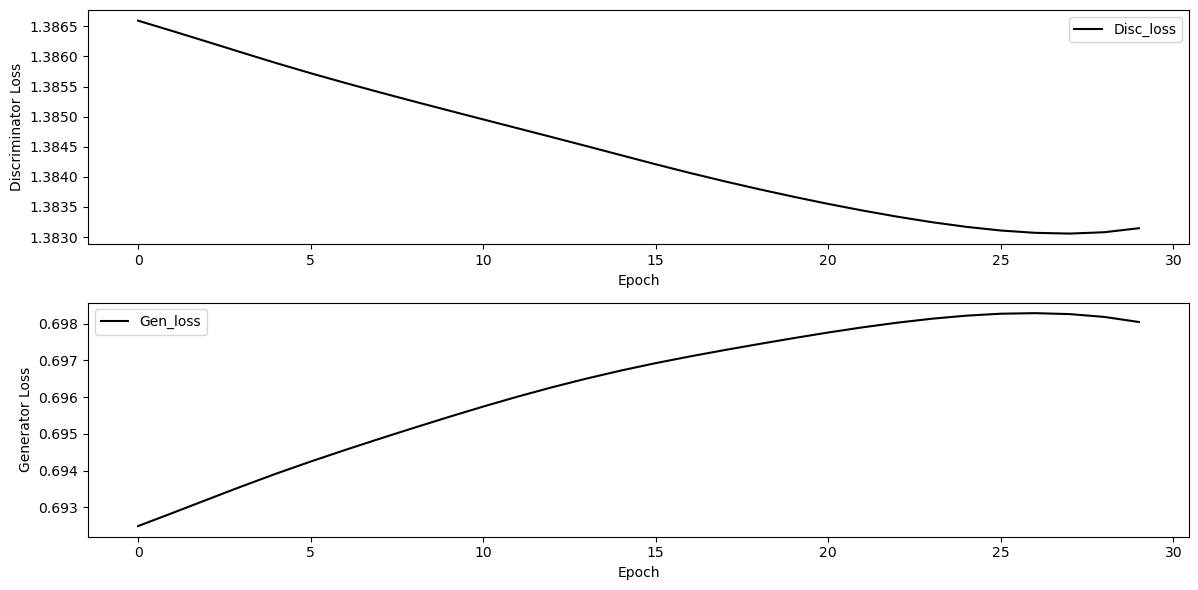

Train relative RMSE: 44842079.281806946


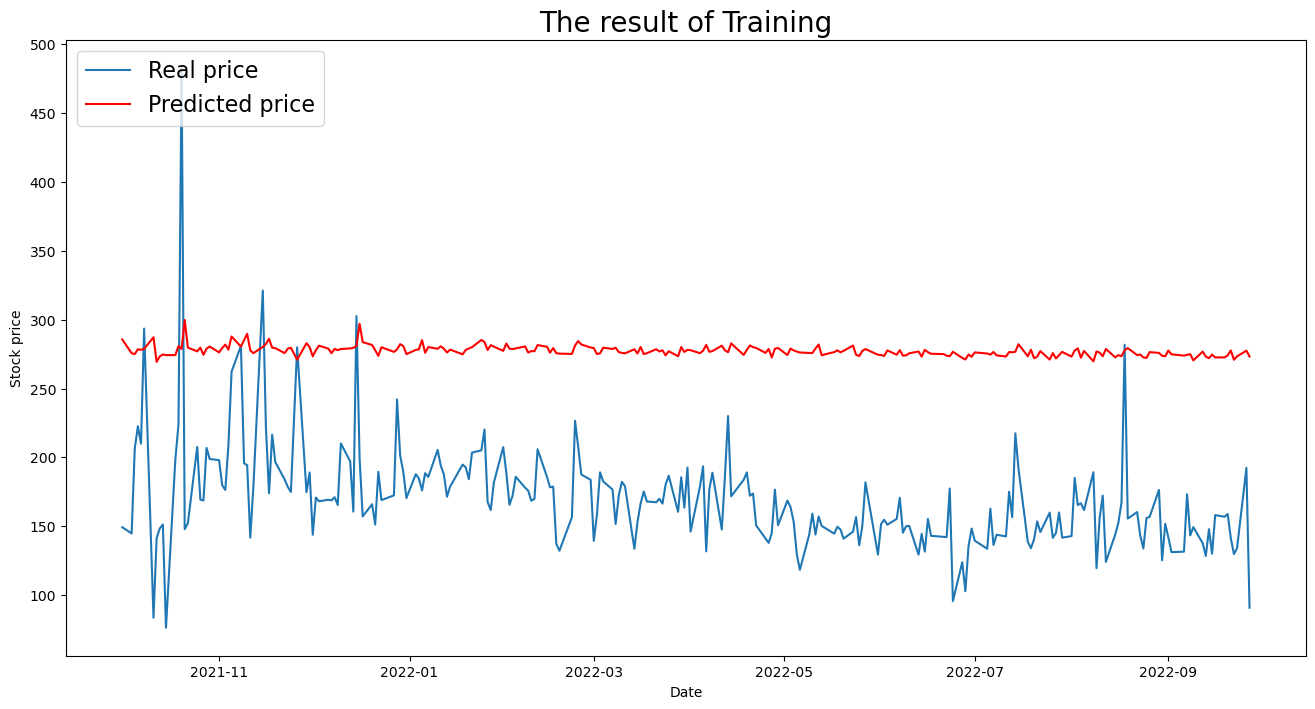

-- Train RMSE -- 114.28261


2026-03-28 09:18:13.639127: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Test RMSE: 112.42844553503208


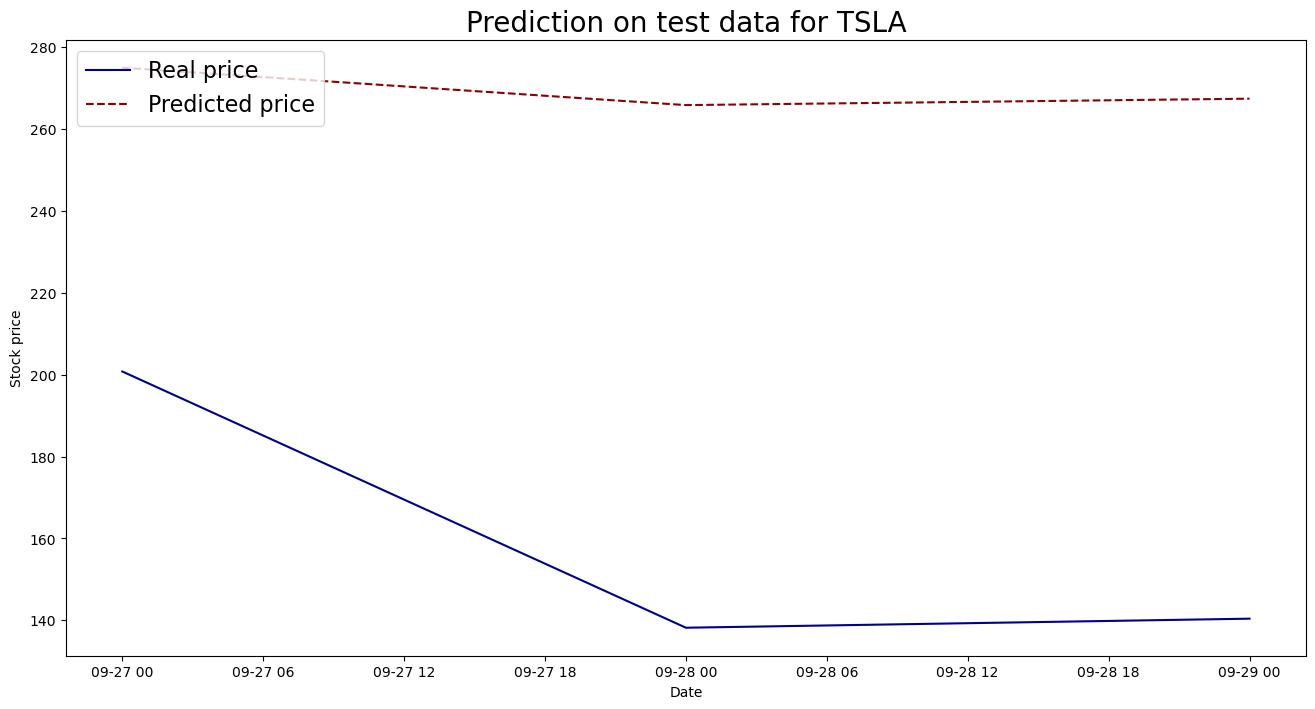

{'train_rmse': 114.28260803222656, 'test_rmse': 112.42844553503208}


In [61]:
# Fast, runnable GAN training + evaluation
EPOCHS = 30
CHECKPOINT = 0  # set >0 only if you want model files saved periodically
LEARNING_RATE = 1e-4

generator = make_generator_model(input_dim, output_dim, feature_size)
discriminator = make_discriminator_model(input_dim)

g_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

Predicted_price, Real_price, train_error = train(
    X_train, y_train, yc_train,
    EPOCHS,
    generator, discriminator,
    g_optimizer, d_optimizer,
    checkpoint=CHECKPOINT
)

print('Train relative RMSE:', train_error)
train_rmse = plot_results(Real_price, Predicted_price, index_train)

Predicted_test_data = eval_op(generator, X_test).numpy()
test_rmse = plot_test_data(y_test, Predicted_test_data, index_test)

print({'train_rmse': float(train_rmse), 'test_rmse': float(test_rmse)})


In [62]:
print('Generator input shape:', X_train.shape)
print('Discriminator condition shape:', yc_train.shape)
print('Output dimension:', output_dim)


Generator input shape: (1698, 5, 25)
Discriminator condition shape: (1698, 5, 1)
Output dimension: 1


In [63]:
generator.summary()
discriminator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 1024)        │     4,300,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 512)         │     3,147,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 256)         │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,313 (32.37 MB)

 Trainable params: 8,485,313 (32.37 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 8)           │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 16)          │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1, 220)         │        28,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 1, 220)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1, 220)         │        48,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1, 1)           │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,309 (364.49 KB)

 Trainable params: 93,309 (364.49 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Optional extra training (run only if needed)
EXTRA_EPOCHS = 0
if EXTRA_EPOCHS > 0:
    Predicted_price, Real_price, train_error = train(
        X_train, y_train, yc_train,
        EXTRA_EPOCHS,
        generator, discriminator,
        g_optimizer, d_optimizer,
        checkpoint=0
    )
    print('Extra training relative RMSE:', train_error)


Test RMSE: 112.42844553503208


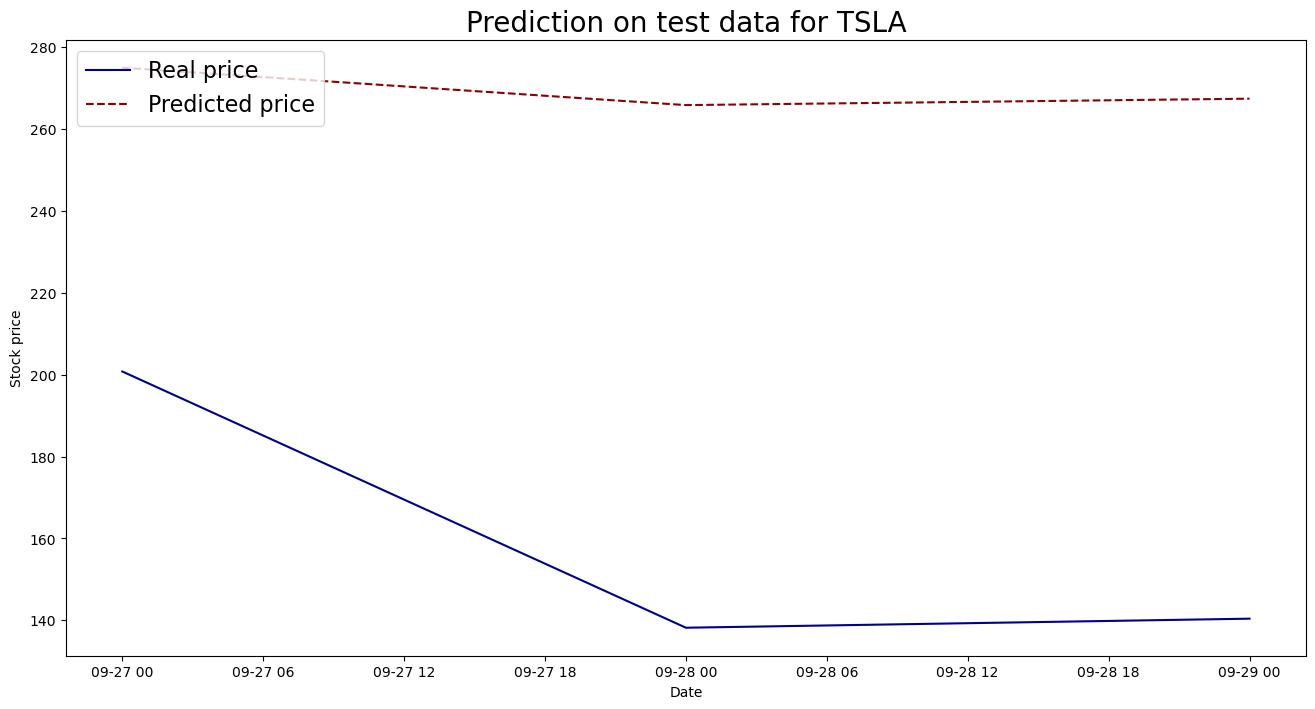

112.42844553503208

In [65]:
Predicted_test_data = eval_op(generator, X_test).numpy()
plot_test_data(y_test, Predicted_test_data, index_test)


In [66]:
pd.DataFrame({'metric': ['train_rmse', 'test_rmse'], 'value': [train_rmse, test_rmse]})


,metric,value
0,train_rmse,114.282608
1,test_rmse,112.428446


## Conclusion

This project demonstrates an end-to-end pipeline for stock market sentiment analysis by combining tweet sentiment with historical market data and machine learning/deep learning workflows. The experiments show that sentiment-derived features can provide useful signal for stock movement analysis, while model performance depends heavily on data quality, feature engineering, and temporal alignment.

### Key Takeaways

- VADER-based sentiment scoring offers a simple and effective baseline for tweet sentiment extraction.
- Aggregating sentiment by stock and date helps reduce tweet-level noise.
- Integrating sentiment with market indicators improves analytical depth over using price-only features.
- Model evaluation should prioritize robustness and generalization across time periods.

### Limitations

- Sentiment does not directly imply price direction in all market regimes.
- Tweet data can be noisy, biased, and sensitive to major events.
- Results may vary by stock, timeframe, and preprocessing strategy.

### Future Work

- Use transformer-based sentiment models for better context handling.
- Add event-aware and macroeconomic features.
- Perform walk-forward validation and stronger backtesting.
- Deploy a production-ready inference pipeline with monitoring.

Overall, this notebook provides a strong foundation for building sentiment-enhanced stock analysis systems and can be extended into a full trading research workflow.
